<a href="https://colab.research.google.com/github/sr-bn98/skills__proj/blob/main/LinearModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project investigates the robustness of foundation models, particularly in the context of augmentations. We utilize the pre-split MIMIC Chest X-ray dataset (n = 238,909), focusing on AP/PA images associated with Cardiomegaly (prevalence = 0.19) and Pneumothorax (prevalence = 0.05).

The dataset is divided into training and validation subsets (70/30 split) for model development. To evaluate performance, we extract embeddings from the RAD-DINO self-supervised vision transformer model and use them to train a multiclass linear model. The model is then applied to a separately curated test set, enabling us to assess generalization and stability.

By leveraging RAD-DINO embeddings for augmentation, we aim to enhance performance and robustness in the classification task. These embeddings serve as inputs to a linear model, which undergoes further training to refine predictions and optimize results.

In [ ]:
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim


In [ ]:
from google.colab import files
files.upload()
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d sarabana/drkhosravi

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sarabana/drkhosravi
License(s): unknown
 97% 858M/881M [00:04<00:00, 112MB/s] 
100% 881M/881M [00:04<00:00, 216MB/s]


In [ ]:
!unzip -q drkhosravi.zip

In [ ]:
print(os.getcwd())
print(os.listdir())

/content
['.config', 'labels.csv', 'drkhosravi.zip', 'mimic_cxr_metadata.csv', '12_post_norm', 'dino_inference.py', 'sample_data']


In [ ]:
red_dino_df = pd.read_csv('/content/labels.csv')
labels_df = pd.read_csv('/content/mimic_cxr_metadata.csv')

In [ ]:
print(labels_df.head())
print('---------------------------------------------------------------------\n')
print(red_dino_df.head())

                                       dicom_id  subject_id  study_id  \
0  02aa804e-bde0afdd-112c0b34-7bc16630-4e384014    10000032  50414267   
1  174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962    10000032  50414267   
2  2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab    10000032  53189527   
3  e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c    10000032  53189527   
4  68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714    10000032  53911762   

  PerformedProcedureStepDescription ViewPosition  Rows  Columns  StudyDate  \
0                CHEST (PA AND LAT)           PA  3056     2544   21800506   
1                CHEST (PA AND LAT)      LATERAL  3056     2544   21800506   
2                CHEST (PA AND LAT)           PA  3056     2544   21800626   
3                CHEST (PA AND LAT)      LATERAL  3056     2544   21800626   
4               CHEST (PORTABLE AP)           AP  2705     2539   21800723   

    StudyTime ProcedureCodeSequence_CodeMeaning ViewCodeSequence_CodeMeaning  \
0  213014.53

In [ ]:
labels_df['Split'].value_counts()

,count
Split,
train,368960
test,5159
validate,2991


In [ ]:
merged_df = pd.merge(labels_df, red_dino_df, on='study_id', how='left')
merged_df= merged_df.fillna(0)
merged_df = merged_df.replace(-1, 1)
merged_df.groupby("Split")[["Cardiomegaly", "Pneumothorax"]].apply(lambda x: x.value_counts())

Cardiomegaly,0.0,1.0,0.0,1.0
Pneumothorax,0.0,0.0,1.0,1.0
Split,,,,
test,3594,1394,143,28
train,285891,67545,12301,3223
validate,2262,605,104,20


In [ ]:
labels_df = labels_df[labels_df['ViewPosition'].isin(['PA','AP'])]
labels_df = labels_df[labels_df['ViewCodeSequence_CodeMeaning'].isin(['postero-anterior','antero-posterior'])]
labels_df = labels_df[labels_df['Split'].isin(['train','validate'])]
labels_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 238909 entries, 0 to 377109
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   dicom_id                                    238909 non-null  object 
 1   subject_id                                  238909 non-null  int64  
 2   study_id                                    238909 non-null  int64  
 3   PerformedProcedureStepDescription           221589 non-null  object 
 4   ViewPosition                                238909 non-null  object 
 5   Rows                                        238909 non-null  int64  
 6   Columns                                     238909 non-null  int64  
 7   StudyDate                                   238909 non-null  int64  
 8   StudyTime                                   238909 non-null  float64
 9   ProcedureCodeSequence_CodeMeaning           238909 non-null  object 
 10  V

In [ ]:
merged_df = pd.merge(labels_df, red_dino_df, on='study_id', how='left')
print(merged_df.head())
print(merged_df.info())

                                       dicom_id  subject_id_x  study_id  \
0  02aa804e-bde0afdd-112c0b34-7bc16630-4e384014      10000032  50414267   
1  2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab      10000032  53189527   
2  68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714      10000032  53911762   
3  fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818      10000032  53911762   
4  ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c      10000032  56699142   

  PerformedProcedureStepDescription ViewPosition  Rows  Columns  StudyDate  \
0                CHEST (PA AND LAT)           PA  3056     2544   21800506   
1                CHEST (PA AND LAT)           PA  3056     2544   21800626   
2               CHEST (PORTABLE AP)           AP  2705     2539   21800723   
3               CHEST (PORTABLE AP)           AP  2906     2258   21800723   
4               CHEST (PORTABLE AP)           AP  3056     2544   21800805   

    StudyTime ProcedureCodeSequence_CodeMeaning  ...  \
0  213014.531           

In [ ]:
merged_df= merged_df.fillna(0)
merged_df = merged_df.replace(-1, 1)
merged_df = merged_df.dropna(subset=['dicom_id'])
unique_subjects=merged_df["subject_id_x"].unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split_idx=int(len(unique_subjects) * 0.3)

val_sub=unique_subjects[:split_idx]
train_sub=unique_subjects[split_idx:]



In [ ]:
merged_df_2 = merged_df[['dicom_id',
                         "Cardiomegaly","Split", 'Pneumothorax' ]]
filtered_train = merged_df_2[
    (merged_df['subject_id_x'].isin(train_sub))
]

filtered_val = merged_df_2[
    (merged_df['subject_id_x'].isin(val_sub))
]

In [ ]:
filtered_train.head()

,dicom_id,Cardiomegaly,Split,Pneumothorax
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,0.0,train,0.0
1,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,0.0,train,0.0
2,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,0.0,train,0.0
3,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,0.0,train,0.0
4,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,0.0,train,0.0


In [ ]:
print(f'the number of each value in trainset ',filtered_train['Cardiomegaly'].value_counts(),'\n -----------------------------------')
print(f'the number of each value in trainset ',filtered_train['Pneumothorax'].value_counts())
print(f'the number of each value in val ',filtered_val['Cardiomegaly'].value_counts(),'\n -----------------------------------')
print(f'the number of each value in val ',filtered_val['Pneumothorax'].value_counts())

the number of each value in trainset  Cardiomegaly
0.0    131125
1.0     37422
Name: count, dtype: int64 
 -----------------------------------
the number of each value in trainset  Pneumothorax
0.0    160067
1.0      8480
Name: count, dtype: int64
the number of each value in val  Cardiomegaly
0.0    54975
1.0    15387
Name: count, dtype: int64 
 -----------------------------------
the number of each value in val  Pneumothorax
0.0    66564
1.0     3798
Name: count, dtype: int64


In [ ]:
directory_path='/content/12_post_norm'
file_path = os.path.join(directory_path, filtered_train.iloc[0]['dicom_id'] + ".pt")
print(file_path)


/content/12_post_norm/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.pt


In [ ]:
def get_feature(directory_path, dataframe, idx):
    dicom_id = dataframe.iloc[idx]['dicom_id']
    file_path = os.path.join(directory_path, dicom_id + ".pt")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return torch.load(file_path, weights_only=True)


class TensorDataset(Dataset):
    def __init__(self, dataframe, directory_path):
        self.dataframe = dataframe
        self.directory_path = directory_path

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        feature = get_feature(self.directory_path, self.dataframe, idx)
        raw_label = self.dataframe.iloc[idx][["Cardiomegaly", "Pneumothorax"]].values.astype(np.float32)
        label = torch.tensor(raw_label, dtype=torch.float)

        return feature, label







train_dataset = TensorDataset(filtered_train, directory_path)
val_dataset = TensorDataset(filtered_val, directory_path)



In [ ]:
print("Training set size:", len(train_dataset))
print("Validation set size:", len(val_dataset))

Training set size: 167207
Validation set size: 72724


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
class MultilabelLinearModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.5):
        super(MultilabelLinearModel, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        x = self.hidden(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x





class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss.mean()


input_size = 768
num_classes=2
hidden_size=128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MultilabelLinearModel(input_size,hidden_size, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = FocalLoss(alpha=1, gamma=2)

Epoch 1/15
Training Loss - Cardiomegaly: 0.0224, Pneumothorax: 0.0224
Training AUC - Cardiomegaly: 0.7756, Pneumothorax: 0.8411
Validation Loss: 0.0240
Validation AUC - Cardiomegaly: 0.7983, Pneumothorax: 0.8704
Best model saved at epoch 1 with validation loss 0.0240
Epoch 2/15
Training Loss - Cardiomegaly: 0.0199, Pneumothorax: 0.0199
Training AUC - Cardiomegaly: 0.7916, Pneumothorax: 0.8700
Validation Loss: 0.0241
Validation AUC - Cardiomegaly: 0.7970, Pneumothorax: 0.8736
Epoch 3/15
Training Loss - Cardiomegaly: 0.0193, Pneumothorax: 0.0193
Training AUC - Cardiomegaly: 0.7968, Pneumothorax: 0.8799
Validation Loss: 0.0232
Validation AUC - Cardiomegaly: 0.8014, Pneumothorax: 0.8746
Best model saved at epoch 3 with validation loss 0.0232
Epoch 4/15
Training Loss - Cardiomegaly: 0.0185, Pneumothorax: 0.0185
Training AUC - Cardiomegaly: 0.8014, Pneumothorax: 0.8879
Validation Loss: 0.0233
Validation AUC - Cardiomegaly: 0.8017, Pneumothorax: 0.8745
Epoch 5/15
Training Loss - Cardiomegaly:

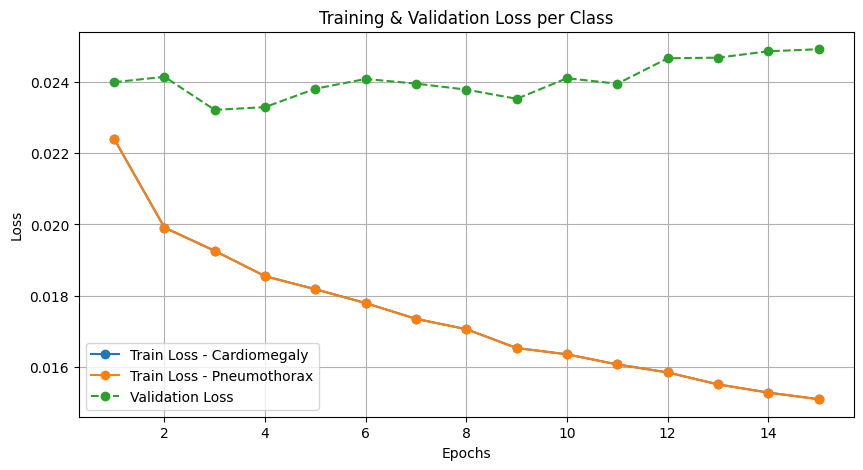

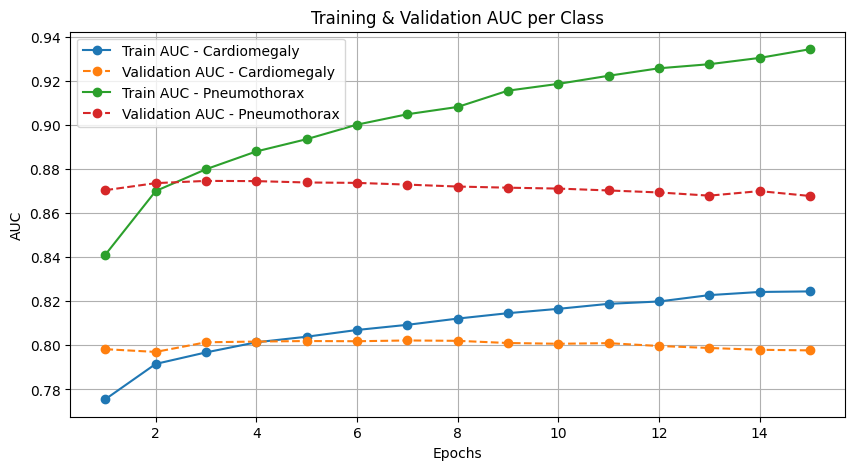

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

num_epochs = 15
best_val_loss = float("inf")
best_model_path = "best_model.pth"

train_loss_history = {"Cardiomegaly": [], "Pneumothorax": []}
train_auc_history = {"Cardiomegaly": [], "Pneumothorax": []}
val_loss_history = []
val_auc_history = {"Cardiomegaly": [], "Pneumothorax": []}
test_loss_history = {"Cardiomegaly": [], "Pneumothorax": []}
test_auc_history = {"Cardiomegaly": [], "Pneumothorax": []}

for epoch in range(num_epochs):
    model.train()
    running_loss = {"Cardiomegaly": 0.0, "Pneumothorax": 0.0}
    train_labels = {"Cardiomegaly": [], "Pneumothorax": []}
    train_preds = {"Cardiomegaly": [], "Pneumothorax": []}

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        loss = criterion(outputs,labels )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        for class_idx, class_name in enumerate(["Cardiomegaly", "Pneumothorax"]):
            running_loss[class_name] += loss.item()
            train_labels[class_name].extend(labels[:, class_idx].cpu().numpy())
            train_preds[class_name].extend(torch.sigmoid(outputs[:, class_idx]).detach().cpu().numpy())

    train_loss = {cls: running_loss[cls] / len(train_loader) for cls in running_loss}
    train_auc = {cls: roc_auc_score(train_labels[cls], train_preds[cls]) for cls in train_labels}

    for cls in train_loss:
        train_loss_history[cls].append(train_loss[cls])
        train_auc_history[cls].append(train_auc[cls])

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss - Cardiomegaly: {train_loss['Cardiomegaly']:.4f}, Pneumothorax: {train_loss['Pneumothorax']:.4f}")
    print(f"Training AUC - Cardiomegaly: {train_auc['Cardiomegaly']:.4f}, Pneumothorax: {train_auc['Pneumothorax']:.4f}")


    model.eval()
    val_running_loss = 0.0
    val_labels = {"Cardiomegaly": [], "Pneumothorax": []}
    val_preds = {"Cardiomegaly": [], "Pneumothorax": []}

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            for class_idx, class_name in enumerate(["Cardiomegaly", "Pneumothorax"]):
                val_labels[class_name].extend(labels[:, class_idx].cpu().numpy())
                val_preds[class_name].extend(torch.sigmoid(outputs[:, class_idx]).cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_loss_history.append(val_loss)

    val_auc = {cls: roc_auc_score(val_labels[cls], val_preds[cls]) for cls in val_labels}
    for cls in val_auc:
        val_auc_history[cls].append(val_auc[cls])

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation AUC - Cardiomegaly: {val_auc['Cardiomegaly']:.4f}, Pneumothorax: {val_auc['Pneumothorax']:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved at epoch {epoch+1} with validation loss {best_val_loss:.4f}")


plt.figure(figsize=(10, 5))
for cls in ["Cardiomegaly", "Pneumothorax"]:
    plt.plot(range(1, num_epochs + 1), train_loss_history[cls], label=f"Train Loss - {cls}", marker='o', linestyle='-')
plt.plot(range(1, num_epochs + 1), val_loss_history, label="Validation Loss", marker='o', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss per Class")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
for cls in ["Cardiomegaly", "Pneumothorax"]:
    plt.plot(range(1, num_epochs + 1), train_auc_history[cls], label=f"Train AUC - {cls}", marker='o', linestyle='-')
    plt.plot(range(1, num_epochs + 1), val_auc_history[cls], label=f"Validation AUC - {cls}", marker='o', linestyle='--')

plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("Training & Validation AUC per Class")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from google.colab import files

torch.save(model, "best_model.pth")
files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>